In [1]:
from netCDF4 import Dataset
import netCDF4 as nc
import numpy as np
import glob
import os
import zipfile
import cdsapi
import pandas as pd
from datetime import datetime, timedelta
from sklearn.linear_model import OrthogonalMatchingPursuit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


import matplotlib.pyplot as plt # for the new numpy and matplotlib to live together I had to downgrade my numpy. 
# maybe it is just my enviroment, I dont know. I used pip install "numpy<2" --force-reinstall for it to work

In [2]:
#pip install -U "numpy<2" "scipy<1.13" "scikit-learn<1.5" pandas matplotlib netCDF4 cdsapi


In [3]:
url = "https://cds.climate.copernicus.eu/api"
key = "something_I_Will_not_share"

c = cdsapi.Client(url=url, key=key)


# This is how I downloaded the data, but you will get it some other way

In [4]:
'''variables = [
    "2m_temperature",
    "skin_temperature",
    "snow_depth",
    "soil_temperature_level_1",
    "soil_temperature_level_2",
    "soil_temperature_level_3",
    "volumetric_soil_water_layer_1",
    "volumetric_soil_water_layer_2",
    "volumetric_soil_water_layer_3",
    "volumetric_soil_water_layer_4",
    "surface_net_thermal_radiation",
    "evaporation_from_bare_soil"
]

for var in variables:
    for year in range(1998, 2001):
        for month in range(1, 13):
            print(f"Downloading {var} {year}-{month:02d} ...")
            c.retrieve(
                "reanalysis-era5-land",
                {
                    "variable": var,
                    "year": str(year),
                    "month": f"{month:02d}",
                    "day": [f"{d:02d}" for d in range(1, 32)],
                    "time": [f"{h:02d}:00" for h in range(24)],
                    "area": [47.442, 19.018, 47.44, 19.02],
                    "format": "netcdf"
                },
                f"{var}_{year}_{month:02d}.nc"
            )

            
            
#1          
#47.4413°N, 19.0179° the place of the garden in Budapest
'''

'variables = [\n    "2m_temperature",\n    "skin_temperature",\n    "snow_depth",\n    "soil_temperature_level_1",\n    "soil_temperature_level_2",\n    "soil_temperature_level_3",\n    "volumetric_soil_water_layer_1",\n    "volumetric_soil_water_layer_2",\n    "volumetric_soil_water_layer_3",\n    "volumetric_soil_water_layer_4",\n    "surface_net_thermal_radiation",\n    "evaporation_from_bare_soil"\n]\n\nfor var in variables:\n    for year in range(1998, 2001):\n        for month in range(1, 13):\n            print(f"Downloading {var} {year}-{month:02d} ...")\n            c.retrieve(\n                "reanalysis-era5-land",\n                {\n                    "variable": var,\n                    "year": str(year),\n                    "month": f"{month:02d}",\n                    "day": [f"{d:02d}" for d in range(1, 32)],\n                    "time": [f"{h:02d}:00" for h in range(24)],\n                    "area": [47.442, 19.018, 47.44, 19.02],\n                    "format": "

## I used CDO in bash to merge all the files into one big file for each parametre like this:
### cdo mergetime unzipped_data/soil_temperature_level_1_*.nc merged_soil_temperature_level_1.nc

### sometimes the variable name is not easily predictable, so I print them all

In [5]:
dataset_2m = nc.Dataset('merged_2m_temperature.nc', 'r')
print("2m_temperature variable names:",dataset_2m.variables.keys())

dataset_skin = nc.Dataset('merged_skin_temperature.nc', 'r')
print("\n skin_temperature variable names:",dataset_skin.variables.keys()) 

dataset_snow = nc.Dataset('merged_snow_depth.nc', 'r')
print("\n snow_depth variable names:",dataset_snow.variables.keys()) 

dataset_soil_1 = nc.Dataset('merged_soil_temperature_level_1.nc', 'r')
print("\n soil_temperature_level_1 variable names:",dataset_soil_1.variables.keys()) 

dataset_soil_2 = nc.Dataset('merged_soil_temperature_level_2.nc', 'r')
print("\n soil_temperature_level_2 variable names:",dataset_soil_2.variables.keys()) 

dataset_soil_3 = nc.Dataset('merged_soil_temperature_level_3.nc', 'r')
print("\n soil_temperature_level_3 variable names:",dataset_soil_3.variables.keys()) 

dataset_water_1 = nc.Dataset('merged_volumetric_soil_water_layer_1.nc', 'r')
print("\n volumetric_soil_water_layer_1 variable names:",dataset_water_1.variables.keys()) 

dataset_water_2 = nc.Dataset('merged_volumetric_soil_water_layer_2.nc', 'r')
print("\n volumetric_soil_water_layer_2 variable names:",dataset_water_2.variables.keys()) 

dataset_water_3 = nc.Dataset('merged_volumetric_soil_water_layer_3.nc', 'r')
print("\n volumetric_soil_water_layer_3 variable names:",dataset_water_3.variables.keys()) 

dataset_water_4 = nc.Dataset('merged_volumetric_soil_water_layer_4.nc', 'r')
print("\n volumetric_soil_water_layer_4 variable names:",dataset_water_4.variables.keys()) 

dataset_rad = nc.Dataset('merged_surface_net_thermal_radiation.nc', 'r')
print("\n surface_net_thermal_radiation variable names:",dataset_rad.variables.keys()) 

dataset_evap = nc.Dataset('merged_evaporation_from_bare_soil.nc', 'r')
print("\n evaporation_from_bare_soil variable names:",dataset_evap.variables.keys()) 

2m_temperature variable names: dict_keys(['valid_time', 'longitude', 'latitude', 't2m'])

 skin_temperature variable names: dict_keys(['valid_time', 'longitude', 'latitude', 'skt'])

 snow_depth variable names: dict_keys(['valid_time', 'longitude', 'latitude', 'sde'])

 soil_temperature_level_1 variable names: dict_keys(['valid_time', 'longitude', 'latitude', 'stl1'])

 soil_temperature_level_2 variable names: dict_keys(['valid_time', 'longitude', 'latitude', 'stl2'])

 soil_temperature_level_3 variable names: dict_keys(['valid_time', 'longitude', 'latitude', 'stl3'])

 volumetric_soil_water_layer_1 variable names: dict_keys(['valid_time', 'longitude', 'latitude', 'swvl1'])

 volumetric_soil_water_layer_2 variable names: dict_keys(['valid_time', 'longitude', 'latitude', 'swvl2'])

 volumetric_soil_water_layer_3 variable names: dict_keys(['valid_time', 'longitude', 'latitude', 'swvl3'])

 volumetric_soil_water_layer_4 variable names: dict_keys(['valid_time', 'longitude', 'latitude', 'sw

In [6]:

time_vars = {
    "2m_temperature": dataset_2m.variables["valid_time"][:],
    "skin_temperature": dataset_skin.variables["valid_time"][:],
    "snow_depth": dataset_snow.variables["valid_time"][:],
    "soil_temp_lvl_1": dataset_soil_1.variables["valid_time"][:],
    "soil_temp_lvl_2": dataset_soil_2.variables["valid_time"][:],
    "soil_temp_lvl_3": dataset_soil_3.variables["valid_time"][:],
    "soil_water_lvl_1": dataset_water_1.variables["valid_time"][:],
    "soil_water_lvl_2": dataset_water_2.variables["valid_time"][:],
    "soil_water_lvl_3": dataset_water_3.variables["valid_time"][:],
    "soil_water_lvl_4": dataset_water_4.variables["valid_time"][:],
    "thermal_radiation": dataset_rad.variables["valid_time"][:],
    "evaporation_bare_soil": dataset_evap.variables["valid_time"][:]
}

# Compare each one against 2m_temperature as the reference
ref_name = "2m_temperature"
ref_time = time_vars[ref_name]

print(f"Reference: {ref_name} (length {len(ref_time)})\n")

for name, t in time_vars.items():
    if np.array_equal(ref_time, t):
        print(f" {name}: same time axis")
    else:
        # check if only length differs or content too
        if len(ref_time) != len(t):
            print(f" {name}: different length ({len(t)} vs {len(ref_time)})")
        else:
            diff_count = np.sum(ref_time != t)
            print(f" {name}: {diff_count} differing time entries")


Reference: 2m_temperature (length 298056)

 2m_temperature: same time axis
 skin_temperature: same time axis
 snow_depth: same time axis
 soil_temp_lvl_1: same time axis
 soil_temp_lvl_2: same time axis
 soil_temp_lvl_3: different length (165816 vs 298056)
 soil_water_lvl_1: same time axis
 soil_water_lvl_2: same time axis
 soil_water_lvl_3: same time axis
 soil_water_lvl_4: same time axis
 thermal_radiation: same time axis
 evaporation_bare_soil: same time axis


In [7]:
temperature_2m = dataset_2m.variables['t2m'][:]
time = dataset_2m.variables['valid_time'][:]

temperature_skin = dataset_skin.variables['skt'][:]

snow_depth = dataset_snow.variables['sde'][:]

soil_temp_1 = dataset_soil_1.variables['stl1'][:]
soil_temp_2 = dataset_soil_2.variables['stl2'][:]
soil_temp_3 = dataset_soil_3.variables['stl3'][:]
time_soil_3 = dataset_soil_3.variables['valid_time'][:]


soil_water_1 = dataset_water_1.variables['swvl1'][:]
soil_water_2 = dataset_water_2.variables['swvl2'][:]
soil_water_3 = dataset_water_3.variables['swvl3'][:]
soil_water_4 = dataset_water_4.variables['swvl4'][:]

thermal_radiation = dataset_rad.variables['str'][:]
evaporation_bare_soil = dataset_evap.variables['evabs'][:]

print("All variables extracted successfully!")
print("Shapes:")
print("t2m:", temperature_2m.shape)
print("skt:", temperature_skin.shape)
print("sde:", snow_depth.shape)
print("stl1:", soil_temp_1.shape)
print("stl12:", soil_temp_2.shape)
print("stl13:", soil_temp_3.shape)
print("swvl1:", soil_water_1.shape)
print("swvl2:", soil_water_2.shape)
print("swvl3:", soil_water_3.shape)
print("swvl4:", soil_water_4.shape)
print("str:", thermal_radiation.shape)
print("evabs:", evaporation_bare_soil.shape)
print("time:",time.shape)
print("time_soil_3:",time_soil_3.shape)


All variables extracted successfully!
Shapes:
t2m: (298056, 1, 1)
skt: (298056, 1, 1)
sde: (298056, 1, 1)
stl1: (298056, 1, 1)
stl12: (298056, 1, 1)
stl13: (165816, 1, 1)
swvl1: (298056, 1, 1)
swvl2: (298056, 1, 1)
swvl3: (298056, 1, 1)
swvl4: (298056, 1, 1)
str: (298056, 1, 1)
evabs: (298056, 1, 1)
time: (298056,)
time_soil_3: (165816,)


In [8]:


dataset_2m.close()
dataset_skin.close()
dataset_snow.close()
dataset_soil_1.close()
dataset_soil_2.close()
dataset_soil_3.close()
dataset_water_1.close()
dataset_water_2.close()
dataset_water_3.close()
dataset_water_4.close()
dataset_rad.close()
dataset_evap.close()

print(" All NetCDF datasets have been closed successfully.")


 All NetCDF datasets have been closed successfully.


In [9]:
df_raw = pd.read_csv("V_KEZD_Excel_SORTED_cut.csv")

In [10]:


years = df_raw.iloc[0, 1:34].astype(float).astype(int).tolist()  # 1968–2000 columns
print("Years:", years)

df_values = df_raw.iloc[1:, 1:34]
df_values.columns = years

df_values.insert(0, "specimen_id", range(1, len(df_values) + 1))

df_long = df_values.melt(id_vars="specimen_id", var_name="year", value_name="DOY")

df_long = df_long.dropna(subset=["DOY"])

print(df_long.head())

Years: [1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000]
   specimen_id  year DOY
0            1  1968  46
1            2  1968  46
3            4  1968  49
7            8  1968  47
8            9  1968  49


In [11]:
df_long["DOY"] = pd.to_numeric(df_long["DOY"], errors='coerce')
df_long = df_long.dropna(subset=["DOY"])
df_long["DOY"] = df_long["DOY"].astype(float)


In [12]:
df_long["year"] = df_long["year"].astype(int)
df_long["flowering_date"] = pd.to_datetime(df_long["year"].astype(str), format="%Y") + \
                            pd.to_timedelta(df_long["DOY"] - 1, unit="D")

print(df_long.head())


   specimen_id  year   DOY flowering_date
0            1  1968  46.0     1968-02-15
1            2  1968  46.0     1968-02-15
3            4  1968  49.0     1968-02-18
7            8  1968  47.0     1968-02-16
8            9  1968  49.0     1968-02-18


In [13]:
print(time[0], time[-1])
time_dt = pd.to_datetime(time, unit='s', origin='1970-01-01')
time_dt2 = pd.to_datetime(time_soil_3, unit='s', origin='1970-01-01')
print(time_dt.min(), time_dt.max())


-94694400.0 978303600.0
1967-01-01 00:00:00 2000-12-31 23:00:00


In [14]:
df = pd.DataFrame({
    'time': time_dt,
    't2m': temperature_2m.flatten(),
    'skt': temperature_skin.flatten(),
    'sde': snow_depth.flatten(),
    'stl1': soil_temp_1.flatten(),
    'stl2': soil_temp_2.flatten(),
    #'stl3': soil_temp_3.flatten(),
    'swvl1': soil_water_1.flatten(),
    'swvl2': soil_water_2.flatten(),
    'swvl3': soil_water_3.flatten(),
    'swvl4': soil_water_4.flatten(),
    'str': thermal_radiation.flatten(),
    'evabs': evaporation_bare_soil.flatten(),
    #'time2': time_dt2
})

df2 = pd.DataFrame({
    'time2':time_dt2,
    'stl3': soil_temp_3.flatten(),
})

In [15]:
df = df.set_index('time')
df2 = df2.set_index('time2')

df = df.resample('D').mean()
df2 = df2.resample('D').mean()

print(df.head())
print(df2.head())

                   t2m         skt       sde        stl1        stl2  \
time                                                                   
1967-01-01  274.653412  273.904053  0.009995  273.479950  273.832672   
1967-01-02  274.274994  273.467896  0.013971  273.727997  274.035278   
1967-01-03  272.847260  271.720184  0.026721  273.617157  274.221527   
1967-01-04  272.316681  271.256592  0.028944  273.030121  273.962555   
1967-01-05  271.026215  269.560852  0.032221  272.839813  273.832886   

               swvl1     swvl2     swvl3     swvl4          str     evabs  
time                                                                       
1967-01-01  0.387596  0.387897  0.374264  0.325439 -1113075.500 -0.000029  
1967-01-02  0.394051  0.388487  0.374755  0.325834 -1476772.625 -0.000020  
1967-01-03  0.386371  0.388397  0.375296  0.326242 -1773600.000 -0.000022  
1967-01-04  0.378423  0.385512  0.375652  0.326655 -3053510.750 -0.000018  
1967-01-05  0.374347  0.382339  0.37575

1967-01-01 00:00:00 → 1985-11-30 00:00:00
Total records: 6909


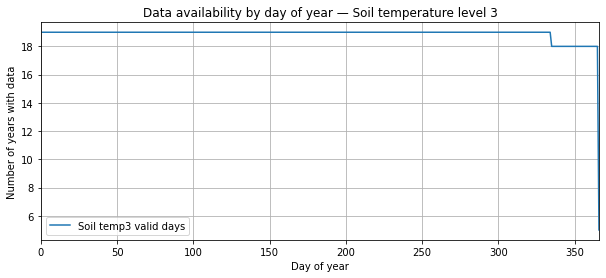

In [16]:
print(df2.index.min(), "→", df2.index.max())
print("Total records:", len(df2))

df2["year"] = df2.index.year
df2["doy"] = df2.index.dayofyear

availability = (
    df2[["doy", "stl3"]]
    .dropna()
    .groupby("doy")
    .size()
)

plt.figure(figsize=(10, 4))
plt.plot(availability.index, availability.values, label="Soil temp3 valid days")
plt.xlabel("Day of year")
plt.ylabel("Number of years with data")
plt.title("Data availability by day of year — Soil temperature level 3")
plt.grid(True)
plt.xlim(0,366)
plt.legend()
plt.show()


In [17]:
# Ensure stl3 is in df2 and has a datetime index (already daily resampled)
df2 = df2.resample('D').mean()

df2 = df2.reindex(df.index)

# Fill missing days with the long-term daily mean (same method as for anomalies)
df2['stl3'] = df2['stl3'].fillna(df2.groupby(df2.index.dayofyear)['stl3'].transform('mean'))

df['stl3'] = df2['stl3']

print(df['stl3'].isna().sum(), "missing values remaining")


0 missing values remaining


In [18]:
print(df.columns)


Index(['t2m', 'skt', 'sde', 'stl1', 'stl2', 'swvl1', 'swvl2', 'swvl3', 'swvl4',
       'str', 'evabs', 'stl3'],
      dtype='object')


In [19]:
# Compute daily climatological mean for each calendar day
df_clim = df.groupby(df.index.dayofyear).transform('mean')

# Compute anomalies (deviation from climatology)
df_anom = df - df_clim

print(df_clim.head())
print(df_clim.describe())



                   t2m         skt       sde        stl1        stl2  \
time                                                                   
1967-01-01  272.040497  271.454376  0.056014  273.668518  274.388336   
1967-01-02  271.924225  271.235229  0.057449  273.640961  274.379456   
1967-01-03  272.143188  271.377747  0.061608  273.678558  274.358856   
1967-01-04  271.984711  270.955933  0.062059  273.708008  274.404541   
1967-01-05  271.411652  270.473816  0.060887  273.581879  274.379517   

               swvl1     swvl2     swvl3     swvl4          str     evabs  \
time                                                                        
1967-01-01  0.355404  0.351172  0.298481  0.286753 -1548432.750 -0.000028   
1967-01-02  0.355263  0.350931  0.300344  0.286863 -1755847.500 -0.000032   
1967-01-03  0.353786  0.349150  0.301464  0.286979 -1749353.000 -0.000031   
1967-01-04  0.358597  0.349417  0.302242  0.287096 -1969870.125 -0.000029   
1967-01-05  0.357501  0.350607  0

In [20]:
L = 300  # history length (days)
vars = df_anom.columns.tolist()
print(f"Using {len(vars)} variables:", vars)


Using 12 variables: ['t2m', 'skt', 'sde', 'stl1', 'stl2', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'str', 'evabs', 'stl3']


In [21]:
X_list = []
y_list = []
used_years = []

for _, row in df_long.iterrows():
    f_date = row["flowering_date"]
    doy = row["DOY"]
    year = row["year"]
    
    # Extract the L-day anomaly window before flowering
    start = f_date - pd.Timedelta(days=L)
    end = f_date

    window = df_anom.loc[start:end]
    
    # Only include if the window is complete (no missing days)
    if len(window) == L + 1:
        X_list.append(window.values.flatten())
        y_list.append(doy)
        used_years.append(year)

X = np.vstack(X_list)
y = np.array(y_list)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (8637, 3612)
Target vector shape: (8637,)


In [22]:
flowering = (
    df_long.groupby("year", as_index=False)["DOY"].min()
)
flowering["flowering_date"] = pd.to_datetime(flowering["year"].astype(str), format="%Y") + \
                              pd.to_timedelta(flowering["DOY"] - 1, unit="D")

print(flowering.head())
print("Years available:", flowering["year"].tolist())


   year   DOY flowering_date
0  1968  46.0     1968-02-15
1  1969  61.0     1969-03-02
2  1970  66.0     1970-03-07
3  1971  39.0     1971-02-08
4  1972  41.0     1972-02-10
Years available: [1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000]


L=100, n=1, R²=0.701
L=100, n=3, R²=0.855
L=100, n=5, R²=0.907
L=100, n=7, R²=0.955
L=100, n=9, R²=0.972
L=150, n=1, R²=0.701
L=150, n=3, R²=0.855
L=150, n=5, R²=0.907
L=150, n=7, R²=0.959
L=150, n=9, R²=0.981
L=200, n=1, R²=0.701
L=200, n=3, R²=0.894
L=200, n=5, R²=0.941
L=200, n=7, R²=0.965
L=200, n=9, R²=0.988
L=250, n=1, R²=0.701
L=250, n=3, R²=0.894
L=250, n=5, R²=0.941
L=250, n=7, R²=0.966
L=250, n=9, R²=0.985
L=300, n=1, R²=0.701
L=300, n=3, R²=0.888
L=300, n=5, R²=0.958
L=300, n=7, R²=0.987
L=300, n=9, R²=0.995


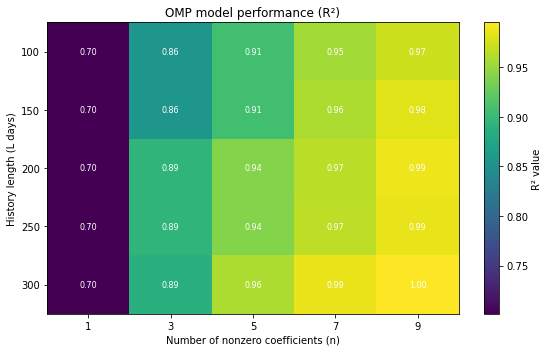

In [23]:

results = []

L_values = [100, 150, 200, 250, 300]     # length of climate history
n_values = [1, 3, 5, 7, 9]               # number of nonzero coefficients

for L in L_values:
    for n_nonzero in n_values:
        X_list = []
        y_list = []
        used_years = []

        for _, row in flowering.iterrows():
            f_date = row["flowering_date"]
            doy = row["DOY"]
            year = row["year"]

            start = f_date - pd.Timedelta(days=L)
            end = f_date
            window = df_anom.loc[start:end]

            if len(window) == L + 1:
                X_list.append(window.values.flatten())
                y_list.append(doy)
                used_years.append(year)

        if len(X_list) == 0:
            continue

        X = np.vstack(X_list)
        y = np.array(y_list)

        # Normalize and fit
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        omp = OrthogonalMatchingPursuit(n_nonzero_coefs=n_nonzero)
        omp.fit(X_scaled, y)
        r2 = omp.score(X_scaled, y)

        results.append((L, n_nonzero, r2))
        print(f"L={L}, n={n_nonzero}, R²={r2:.3f}")

# Convert results to DataFrame
df_results = pd.DataFrame(results, columns=["L_days", "n_nonzero", "R2"])

# Create a pivot table for visualization
pivot = df_results.pivot(index="L_days", columns="n_nonzero", values="R2")

# --- Plot heatmap manually using matplotlib ---
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("R² value")

# Axis labels and ticks
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel("Number of nonzero coefficients (n)")
ax.set_ylabel("History length (L days)")
ax.set_title("OMP model performance (R²)")

# Annotate cells with R² values
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        r2_value = pivot.values[i, j]
        ax.text(j, i, f"{r2_value:.2f}", ha="center", va="center", color="white", fontsize=8)

plt.tight_layout()
plt.show()


In [24]:
# --- Find the best-performing (L, n_nonzero) combination ---
best_row = df_results.loc[df_results["R2"].idxmax()]
best_L = int(best_row["L_days"])
best_n = int(best_row["n_nonzero"])
best_R2 = best_row["R2"]
best_L = 250
best_n = 6
print(f"🌸 Best model: L = {best_L}, n_nonzero = {best_n}, R² = {best_R2:.3f}")

# --- Recreate the best dataset ---
X_list, y_list, used_years = [], [], []

for _, row in flowering.iterrows():
    f_date = row["flowering_date"]
    doy = row["DOY"]
    year = row["year"]

    start = f_date - pd.Timedelta(days=best_L)
    end = f_date
    window = df_anom.loc[start:end]

    if len(window) == best_L + 1:
        X_list.append(window.values.flatten())
        y_list.append(doy)
        used_years.append(year)

X = np.vstack(X_list)
y = np.array(y_list)

# --- Fit OMP again ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

omp = OrthogonalMatchingPursuit(n_nonzero_coefs=best_n)
omp.fit(X_scaled, y)
r2 = omp.score(X_scaled, y)

print(f"Refitted R²: {r2:.3f}")


🌸 Best model: L = 250, n_nonzero = 6, R² = 0.995
Refitted R²: 0.954


In [25]:
# Which coefficients are nonzero
coef_mask = np.abs(omp.coef_) > 1e-8
selected_idx = np.where(coef_mask)[0]

vars = df_anom.columns.tolist()
n_vars = len(vars)

selected_info = []

for idx in selected_idx:
    var_idx = idx // (best_L + 1)        # which weather variable
    day_offset = idx % (best_L + 1)      # which day in the window
    variable = vars[var_idx]
    days_before = best_L - day_offset    # convert to "days before flowering"
    coef_val = omp.coef_[idx]
    selected_info.append((variable, days_before, coef_val))

selected_df = pd.DataFrame(selected_info, columns=["Variable", "Days_before_flowering", "Coefficient"])

print("\n Selected predictors (sorted by absolute coefficient):")
print(selected_df.sort_values(by="Coefficient", key=np.abs, ascending=False))



 Selected predictors (sorted by absolute coefficient):
  Variable  Days_before_flowering  Coefficient
4     stl3                    109    11.212234
1     stl2                     81     4.921980
3    evabs                     68    -4.752227
5     stl3                     26     2.722358
2    swvl3                    233     2.204006
0      t2m                    149     1.905166


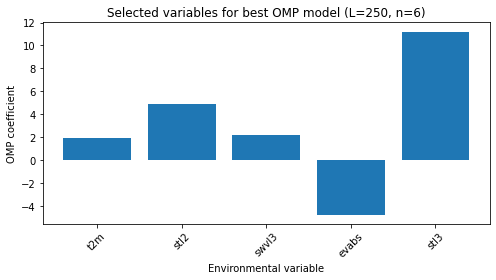

In [26]:


plt.figure(figsize=(7,4))
plt.bar(selected_df["Variable"], selected_df["Coefficient"])
plt.title(f"Selected variables for best OMP model (L={best_L}, n={best_n})")
plt.xlabel("Environmental variable")
plt.ylabel("OMP coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [27]:

flowering = flowering.sort_values("year").reset_index(drop=True)
years_all = flowering["year"].tolist()
print("Years available:", years_all)


Years available: [1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000]


In [28]:
train_years = flowering["year"].iloc[:25]
test_years  = flowering["year"].iloc[25:]

print(f"Training: {train_years.min()}–{train_years.max()}  "
      f"({len(train_years)} years)")
print(f"Testing:  {test_years.min()}–{test_years.max()}  "
      f"({len(test_years)} years)")


Training: 1968–1992  (25 years)
Testing:  1993–2000  (8 years)


In [29]:
def build_X_y(flowering_subset, L, df_anom):
    X_list, y_list, years_used = [], [], []
    for _, row in flowering_subset.iterrows():
        f_date = row["flowering_date"]
        start = f_date - pd.Timedelta(days=L)
        end   = f_date
        window = df_anom.loc[start:end]
        if len(window) == L + 1:
            X_list.append(window.values.flatten())
            y_list.append(row["DOY"])
            years_used.append(row["year"])
    if not X_list:
        return None, None, None
    X = np.vstack(X_list)
    y = np.array(y_list)
    return X, y, years_used

L = 250     
n_nonzero = 6




X_train, y_train, years_train = build_X_y(flowering[flowering["year"].isin(train_years)], L, df_anom)
X_test,  y_test,  years_test  = build_X_y(flowering[flowering["year"].isin(test_years)],  L, df_anom)


In [30]:


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

omp = OrthogonalMatchingPursuit(n_nonzero_coefs=n_nonzero)
omp.fit(X_train_scaled, y_train)

y_pred_train = omp.predict(X_train_scaled)
y_pred_test  = omp.predict(X_test_scaled)

r2_train = omp.score(X_train_scaled, y_train)
r2_test  = omp.score(X_test_scaled, y_test)

print(f"Train R²: {r2_train:.3f}")
print(f"Test  R²: {r2_test:.3f}")


Train R²: 0.982
Test  R²: 0.010


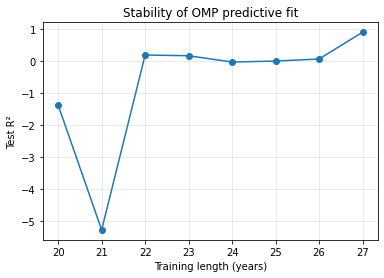

In [31]:
r2_results = []

for train_len in range(20, 28):
    train_years = flowering["year"].iloc[:train_len]
    test_years  = flowering["year"].iloc[train_len:]
    
    X_train, y_train, _ = build_X_y(flowering[flowering["year"].isin(train_years)], L, df_anom)
    X_test,  y_test,  _ = build_X_y(flowering[flowering["year"].isin(test_years)],  L, df_anom)
    if X_test is None: continue
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    omp = OrthogonalMatchingPursuit(n_nonzero_coefs=n_nonzero)
    omp.fit(X_train_scaled, y_train)
    
    r2_test = omp.score(X_test_scaled, y_test)
    r2_results.append((train_len, r2_test))

# Plot stability curve
r2_results = np.array(r2_results)
plt.figure()
plt.plot(r2_results[:,0], r2_results[:,1], "o-")
plt.xlabel("Training length (years)")
plt.ylabel("Test R²")
plt.title("Stability of OMP predictive fit")
plt.grid(True, alpha=0.3)
plt.show()


In [32]:
X_train, y_train, years_train = build_X_y(flowering[flowering["year"].isin(train_years)], L, df_anom)
X_test,  y_test,  years_test  = build_X_y(flowering[flowering["year"].isin(test_years)],  L, df_anom)

# After fitting
y_pred_train = omp.predict(X_train_scaled)
y_pred_test  = omp.predict(X_test_scaled)

# Use years_test here — it has the same length as y_pred_test
residuals = pd.DataFrame({
    "year": years_test,
    "Observed_DOY": y_test,
    "Predicted_DOY": y_pred_test,
})
residuals["Residual"] = residuals["Observed_DOY"] - residuals["Predicted_DOY"]

print(residuals)
print("Mean absolute error:", np.abs(residuals["Residual"]).mean())


   year  Observed_DOY  Predicted_DOY  Residual
0  1995          29.0      32.489437 -3.489437
1  1996          59.0      60.993134 -1.993134
2  1997          30.0      35.764816 -5.764816
3  1998          17.0      20.572392 -3.572392
4  1999          57.0      64.549973 -7.549973
5  2000          32.0      34.467705 -2.467705
Mean absolute error: 4.139575958251953


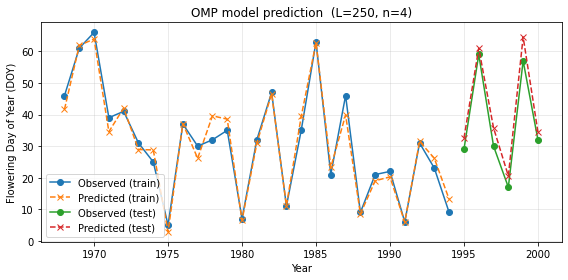

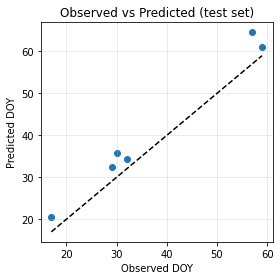

In [33]:
plt.figure(figsize=(8,4))
plt.plot(years_train, y_train, "o-", label="Observed (train)")
plt.plot(years_train, y_pred_train, "x--", label="Predicted (train)")
plt.plot(years_test,  y_test,  "o-", label="Observed (test)")
plt.plot(years_test,  y_pred_test,  "x--", label="Predicted (test)")
plt.xlabel("Year")
plt.ylabel("Flowering Day of Year (DOY)")
plt.title(f"OMP model prediction  (L={best_L}, n={4})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter: observed vs predicted
plt.figure(figsize=(4,4))
plt.scatter(y_test, y_pred_test, color="tab:blue")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], "k--")
plt.xlabel("Observed DOY")
plt.ylabel("Predicted DOY")
plt.title("Observed vs Predicted (test set)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [34]:
# correct:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)  # or fit_transform
X_test_scaled  = scaler.transform(X_test)


In [35]:
mae = np.mean(np.abs(y_test - y_pred_test))
rmse = np.sqrt(np.mean((y_test - y_pred_test)**2))
corr = np.corrcoef(y_test, y_pred_test)[0,1]
print("MAE:", mae, "RMSE:", rmse, "r:", corr)


MAE: 4.139575958251953 RMSE: 4.568652110305943 r: 0.9928415228996565


In [36]:
for n in [1,2,3,4,5,6]:
    omp = OrthogonalMatchingPursuit(n_nonzero_coefs=n)
    omp.fit(X_train_scaled, y_train)
    print("coeff number:",n, "train R2", omp.score(X_train_scaled,y_train), "test R2", omp.score(X_test_scaled,y_test))


coeff number: 1 train R2 0.6672901519998858 test R2 0.8226638378785069
coeff number: 2 train R2 0.784390407261614 test R2 0.9215025810637273
coeff number: 3 train R2 0.890208433339141 test R2 0.865442169902588
coeff number: 4 train R2 0.9205238887721815 test R2 0.8525926471972899
coeff number: 5 train R2 0.9473750067865557 test R2 0.8915780531376337
coeff number: 6 train R2 0.9674248097381669 test R2 0.9118887246974547


In [37]:
print("Selected variable:", selected_df.iloc[0])
print("Selected variable:", selected_df.iloc[1])


Selected variable: Variable                      t2m
Days_before_flowering         149
Coefficient              1.905166
Name: 0, dtype: object
Selected variable: Variable                    stl2
Days_before_flowering         81
Coefficient              4.92198
Name: 1, dtype: object


In [38]:
coef_mask = np.abs(omp.coef_) > 1e-8
idx = np.where(coef_mask)[0][0]
var_idx = idx // (best_L + 1)
lag = best_L - (idx % (best_L + 1))
print(f"Selected variable: {df_anom.columns[var_idx]}, lag: {lag} days before flowering")


Selected variable: stl2, lag: 81 days before flowering


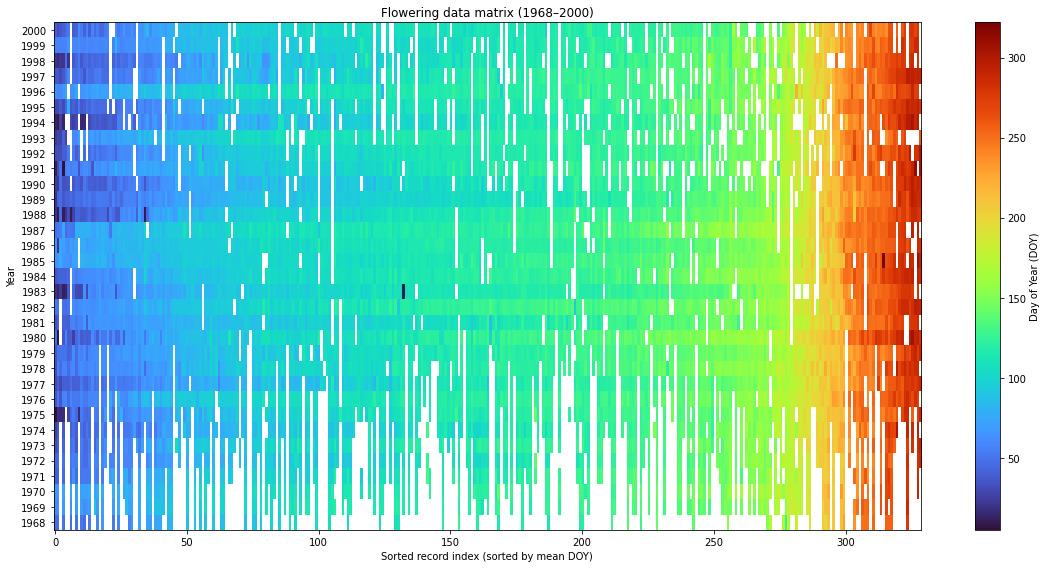

In [39]:

# Pivot the long-format dataframe: rows = years, columns = taxa
flower_matrix = df_long.pivot_table(
    index="year", columns="specimen_id", values="DOY"
)

# Sort columns (taxa) by their mean flowering DOY
mean_doy = flower_matrix.mean()
flower_matrix = flower_matrix[mean_doy.sort_values().index]

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(
    flower_matrix,  
    aspect="auto",
    cmap="turbo",     # or "viridis" / "Spectral"
    origin="lower",
    interpolation="none"
)

# Colourbar
cbar = plt.colorbar(im, ax=ax, label="Day of Year (DOY)")

# Axes labels & ticks
ax.set_xlabel("Sorted record index (sorted by mean DOY)")
ax.set_ylabel("Year")
ax.set_yticks(np.arange(len(flower_matrix.index)))
ax.set_yticklabels(flower_matrix.index)

# White for missing values
im.cmap.set_bad(color="white")

plt.title("Flowering data matrix (1968–2000)")
plt.tight_layout()
plt.show()


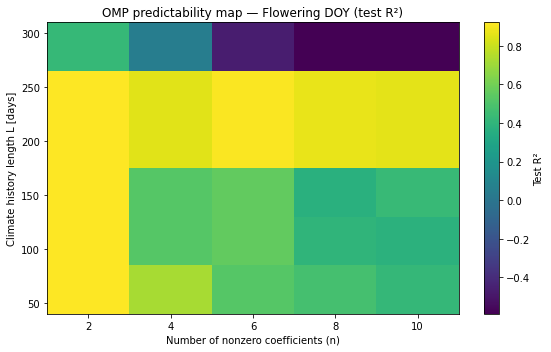

Best parameters: L=50.0, n=2.0, test R²=0.922


In [40]:


# === Parameters to scan ===
L_values = [50, 100, 150, 200, 250, 300]       # length of climate history (days)
n_values = [2, 4, 6, 8, 10]                    # number of nonzero coefficients
results = []

for L in L_values:
    # build training/test sets
    X_train, y_train, years_train = build_X_y(flowering[flowering["year"].isin(train_years)], L, df_anom)
    X_test,  y_test,  years_test  = build_X_y(flowering[flowering["year"].isin(test_years)],  L, df_anom)

    # standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    for n in n_values:
        omp = OrthogonalMatchingPursuit(n_nonzero_coefs=n)
        omp.fit(X_train_scaled, y_train)
        y_pred_train = omp.predict(X_train_scaled)
        y_pred_test  = omp.predict(X_test_scaled)

        r2_train = r2_score(y_train, y_pred_train)
        r2_test  = r2_score(y_test,  y_pred_test)

        results.append({"L": L, "n": n, "r2_train": r2_train, "r2_test": r2_test})

# === Convert results to DataFrame ===
results_df = pd.DataFrame(results)
pivot_r2 = results_df.pivot(index="L", columns="n", values="r2_test")

# === Plot ===
plt.figure(figsize=(8,5))
im = plt.imshow(pivot_r2, origin="lower", cmap="viridis", 
                extent=[min(n_values)-1, max(n_values)+1, min(L_values)-10, max(L_values)+10],
                aspect='auto')

plt.colorbar(im, label="Test R²")
plt.xticks(n_values)
plt.yticks(L_values)
plt.xlabel("Number of nonzero coefficients (n)")
plt.ylabel("Climate history length L [days]")
plt.title("OMP predictability map — Flowering DOY (test R²)")
plt.tight_layout()
plt.show()

# === Optional: print best configuration ===
best_row = results_df.loc[results_df['r2_test'].idxmax()]
print(f"Best parameters: L={best_row.L}, n={best_row.n}, test R²={best_row.r2_test:.3f}")


In [41]:
best_n = 6
best_L = 250

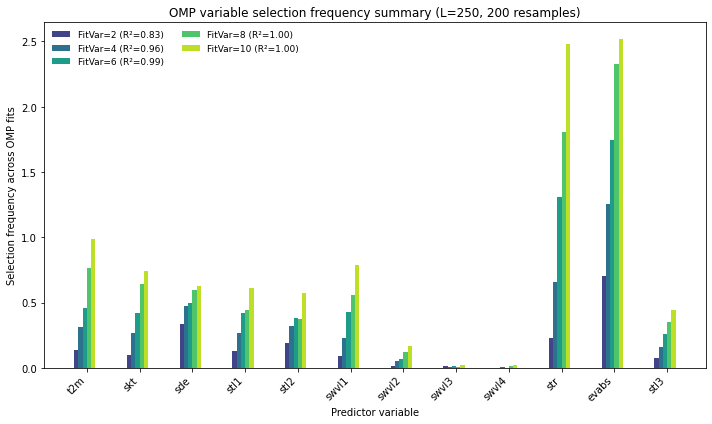

In [42]:


# === Parameters ===
L = 250                     # memory length (e.g. 250)
fitvars = range(2, 12, 2)      # FitVar values 2–12
n_repeats = 200                 # random resampling repetitions
vars_order = list(df_anom.columns)

# === Prepare data ===
X_train, y_train, years_train = build_X_y(flowering[flowering["year"].isin(train_years)], L, df_anom)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

freq_counts = np.zeros((len(vars_order), len(fitvars)))
r2_means = np.zeros(len(fitvars))

# === Run OMP multiple times ===
for j, n in enumerate(fitvars):
    r2_all = []
    for r in range(n_repeats):
        # optional: bootstrap sampling
        idx = np.random.choice(len(X_train_scaled), len(X_train_scaled), replace=True)
        Xs, ys = X_train_scaled[idx], y_train[idx]
        
        omp = OrthogonalMatchingPursuit(n_nonzero_coefs=n)
        omp.fit(Xs, ys)
        r2_all.append(omp.score(Xs, ys))
        
        selected = np.flatnonzero(omp.coef_)
        for idx_sel in selected:
            var_idx = idx_sel % len(vars_order)
            freq_counts[var_idx, j] += 1
    
    r2_means[j] = np.mean(r2_all)

# === Normalize counts by number of runs ===
freq_counts /= n_repeats

# === Plotting ===
plt.figure(figsize=(10, 6))
x = np.arange(len(vars_order))
width = 0.08  # narrower bars for clarity

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(fitvars)))  # distinct hues

for j, n in enumerate(fitvars):
    plt.bar(x + j*width, freq_counts[:, j], width, color=colors[j],
            label=f"FitVar={n} (R²={r2_means[j]:.2f})")

plt.xticks(x + width*(len(fitvars)/2), vars_order, rotation=45, ha='right')
plt.ylabel("Selection frequency across OMP fits")
plt.xlabel("Predictor variable")
plt.title(f"OMP variable selection frequency summary (L={L}, {n_repeats} resamples)")
plt.legend(frameon=False, fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


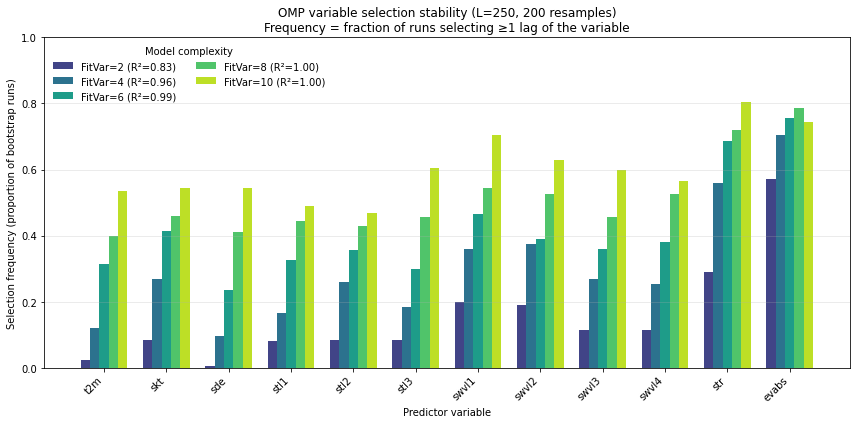

In [43]:
base_variables = [
    't2m',      # 2m temperature
    'skt',      # skin temperature
    'sde',      # snow depth
    'stl1',     # soil temperature level 1
    'stl2',     # soil temperature level 2
    'stl3',     # soil temperature level 3
    'swvl1',    # volumetric soil water layer 1
    'swvl2',    # volumetric soil water layer 2
    'swvl3',    # volumetric soil water layer 3
    'swvl4',    # volumetric soil water layer 4
    'str',      # surface net thermal radiation
    'evabs'     # evaporation from bare soil
]

n_vars = len(base_variables)
L = 250
n_features = n_vars * L

# Then later:
freq_counts = np.zeros((n_vars, len(fitvars)))

for j, n in enumerate(fitvars):
    selected_per_run = np.zeros((n_repeats, n_vars), dtype=bool)

    for r in range(n_repeats):
        idx = np.random.choice(len(X_train_scaled), len(X_train_scaled), replace=True)
        Xs, ys = X_train_scaled[idx], y_train[idx]

        omp = OrthogonalMatchingPursuit(n_nonzero_coefs=n, tol=None)
        omp.fit(Xs, ys)

        selected_indices = np.flatnonzero(omp.coef_)           # e.g. [127, 378, 2411]
        selected_vars = selected_indices // L                  # 0 to n_vars-1

        # This is now safe — even if somehow > n_vars-1 (shouldn't happen)
        valid_vars = selected_vars[selected_vars < n_vars]
        unique_vars = np.unique(valid_vars)

        selected_per_run[r, unique_vars] = True

    freq_counts[:, j] = selected_per_run.mean(axis=0)

# === Plotting ===
plt.figure(figsize=(12, 6))
x = np.arange(n_vars)
width = 0.15
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(fitvars)))

for j, n_fit in enumerate(fitvars):
    plt.bar(x + j*width, freq_counts[:, j], width, color=colors[j],
            label=f"FitVar={n_fit} (R²={r2_means[j]:.2f})")

plt.xticks(x + width*(len(fitvars)-1)/2, base_variables, rotation=45, ha='right')
plt.ylabel("Selection frequency (proportion of bootstrap runs)")
plt.xlabel("Predictor variable")
plt.title(f"OMP variable selection stability (L={L}, {n_repeats} resamples)\n"
          "Frequency = fraction of runs selecting ≥1 lag of the variable")
plt.legend(title="Model complexity", frameon=False, ncol=2)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

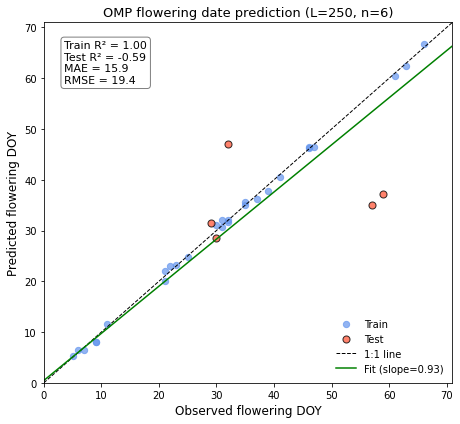

In [44]:



# === Compute statistics ===
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

# === Build plot ===
fig, ax = plt.subplots(figsize=(6.5, 6))

# 1️⃣ Scatter of observed vs predicted DOY
ax.scatter(y_train, y_pred_train, color='cornflowerblue', alpha=0.7, s=40, label='Train')
ax.scatter(y_test, y_pred_test, color='tomato', alpha=0.8, s=50, edgecolor='k', label='Test')

# 2️⃣ 1:1 reference line
lims = [min(y_train.min(), y_test.min()) - 5, max(y_train.max(), y_test.max()) + 5]
ax.plot(lims, lims, 'k--', lw=1, label='1:1 line')

# 3️⃣ Regression fit for all data (optional)
coeffs = np.polyfit(np.concatenate([y_train, y_test]),
                    np.concatenate([y_pred_train, y_pred_test]), 1)
fit_line = np.polyval(coeffs, lims)
ax.plot(lims, fit_line, color='green', lw=1.5, label=f"Fit (slope={coeffs[0]:.2f})")

# 4️⃣ Labels & layout
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Observed flowering DOY", fontsize=12)
ax.set_ylabel("Predicted flowering DOY", fontsize=12)
ax.set_title(f"OMP flowering date prediction (L={L}, n={n_nonzero})", fontsize=13)
ax.legend(frameon=False, fontsize=10)

# 5️⃣ Annotate with metrics
text = f"Train R² = {r2_train:.2f}\nTest R² = {r2_test:.2f}\nMAE = {mae_test:.1f}\nRMSE = {rmse_test:.1f}"
ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=11,
        va='top', ha='left', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"))

plt.tight_layout()
plt.show()


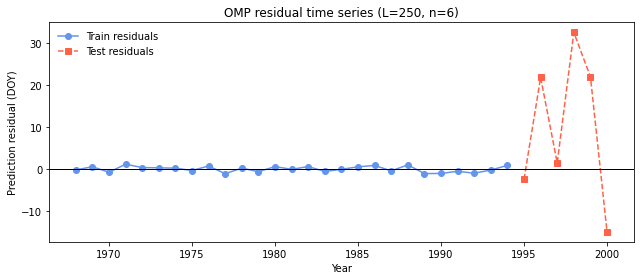

In [45]:
plt.figure(figsize=(9,4))
plt.plot(years_train, y_train - y_pred_train, "o-", color='cornflowerblue', label="Train residuals")
plt.plot(years_test, y_test - y_pred_test, "s--", color='tomato', label="Test residuals")
plt.axhline(0, color='k', lw=1)
plt.xlabel("Year")
plt.ylabel("Prediction residual (DOY)")
plt.title(f"OMP residual time series (L={L}, n={n_nonzero})")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
